In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")

engine = create_engine("postgresql://noam@localhost/phenology_dw")


In [3]:
SPRING_EVENTS = "('Flowering', 'Spring development')"
AUTUMN_EVENTS = "('Emergence', 'Senescence')"

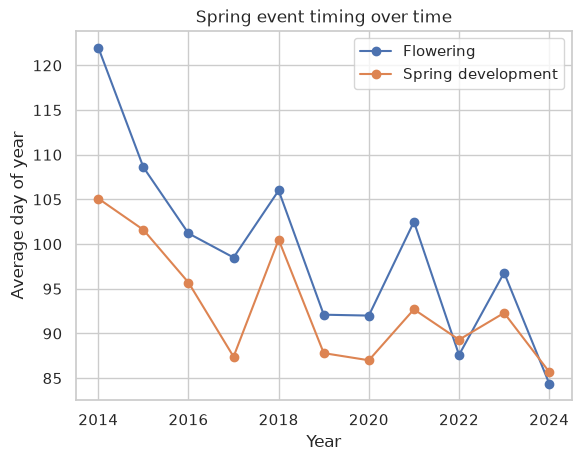

In [31]:

df = pd.read_sql(f"""
    SELECT d.year, ec.event_category,
           ROUND(AVG(f.day_of_year), 1) AS avg_event_day
    FROM fact_phenology_observation f
    JOIN dim_date d            ON d.date_id            = f.date_id
    JOIN dim_event e           ON e.event_id           = f.event_id
    JOIN dim_event_category ec ON ec.event_category_id = e.event_category_id
    WHERE ec.event_category IN {SPRING_EVENTS}
    GROUP BY d.year, ec.event_category
    ORDER BY d.year
""", engine)

for cat, group in df.groupby('event_category'):
    plt.plot(group.year, group.avg_event_day, 'o-', label=cat)
plt.xlabel('Year')
plt.ylabel('Average day of year')
plt.title('Spring event timing over time')
plt.legend()
plt.show()

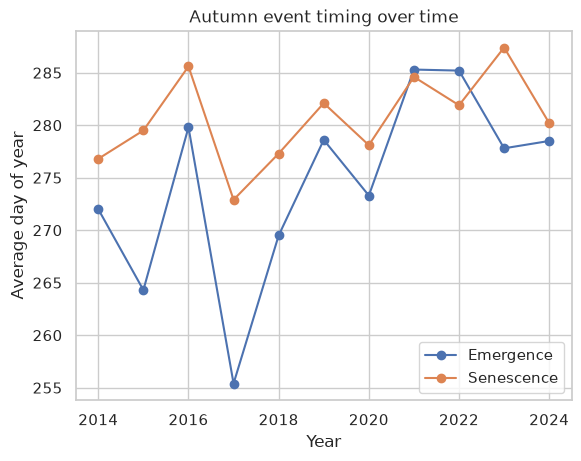

In [36]:
df = pd.read_sql(f"""
    SELECT d.year, ec.event_category,
           ROUND(AVG(f.day_of_year), 1) AS avg_event_day
    FROM fact_phenology_observation f
    JOIN dim_date d            ON d.date_id            = f.date_id
    JOIN dim_event e           ON e.event_id           = f.event_id
    JOIN dim_event_category ec ON ec.event_category_id = e.event_category_id
    WHERE ec.event_category IN {AUTUMN_EVENTS}
    GROUP BY d.year, ec.event_category
    ORDER BY d.year
""", engine)

for cat, group in df.groupby('event_category'):
    plt.plot(group.year, group.avg_event_day, 'o-', label=cat)
plt.xlabel('Year')
plt.ylabel('Average day of year')
plt.title('Autumn event timing over time')
plt.legend()
plt.show()

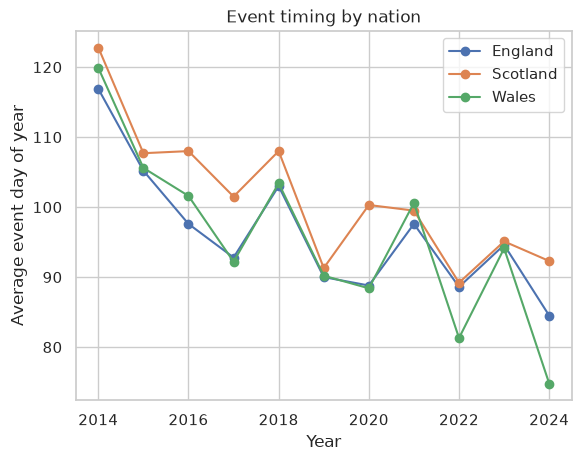

In [27]:
df = pd.read_sql("""
    SELECT d.year, n.nation,
           ROUND(AVG(f.day_of_year), 1) AS avg_event_day
    FROM fact_phenology_observation f
    JOIN dim_date d            ON d.date_id            = f.date_id
    JOIN dim_location l        ON l.location_id        = f.location_id
    JOIN dim_region r          ON r.region_id          = l.region_id
    JOIN dim_nation n          ON n.nation_id          = r.nation_id
    JOIN dim_event e           ON e.event_id           = f.event_id
    JOIN dim_event_category ec ON ec.event_category_id = e.event_category_id
    WHERE ec.event_category IN ('Flowering', 'Spring development')
    AND n.nation IN ('England', 'Scotland', 'Wales')
    GROUP BY d.year, n.nation ORDER BY d.year
""", engine)

for nation, group in df.groupby('nation'):
    plt.plot(group.year, group.avg_event_day, 'o-', label=nation)
plt.xlabel('Year')
plt.ylabel('Average event day of year')
plt.title('Event timing by nation')
plt.legend()
plt.show()

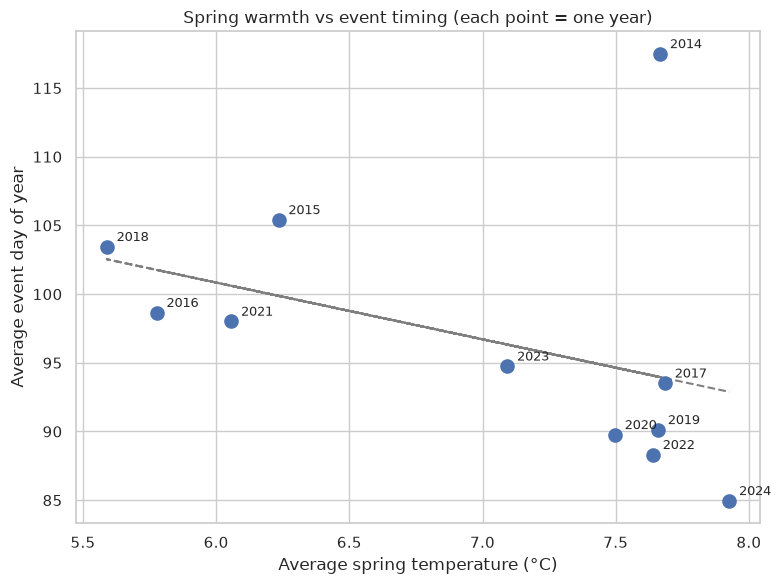

In [ ]:

q2 = f"""
    SELECT d.year,
           AVG(f.day_of_year)      AS avg_event_day,
           AVG(f.temp_mean_spring) AS avg_spring_temp
    FROM fact_phenology_observation f
    JOIN dim_date d            ON d.date_id            = f.date_id
    JOIN dim_event e           ON e.event_id           = f.event_id
    JOIN dim_event_category ec ON ec.event_category_id = e.event_category_id
    WHERE ec.event_category IN {SPRING_EVENTS}
    GROUP BY d.year
    ORDER BY d.year
"""
df2 = pd.read_sql(q2, engine)
 
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df2.avg_spring_temp, df2.avg_event_day, s=90, zorder=3)
for _, r in df2.iterrows():
    ax.annotate(int(r.year), (r.avg_spring_temp, r.avg_event_day),
                textcoords="offset points", xytext=(7, 4), fontsize=9)
 
# Least-squares trend line
m, b = pd.np.polyfit(df2.avg_spring_temp, df2.avg_event_day, 1) \
    if hasattr(pd, "np") else __import__("numpy").polyfit(
        df2.avg_spring_temp, df2.avg_event_day, 1)
xs = df2.avg_spring_temp
ax.plot(xs, m * xs + b, "--", color="grey", zorder=2)
 
ax.set_xlabel("Average spring temperature (°C)")
ax.set_ylabel("Average event day of year")
ax.set_title("Spring warmth vs event timing (each point = one year)")
plt.tight_layout()
plt.show()


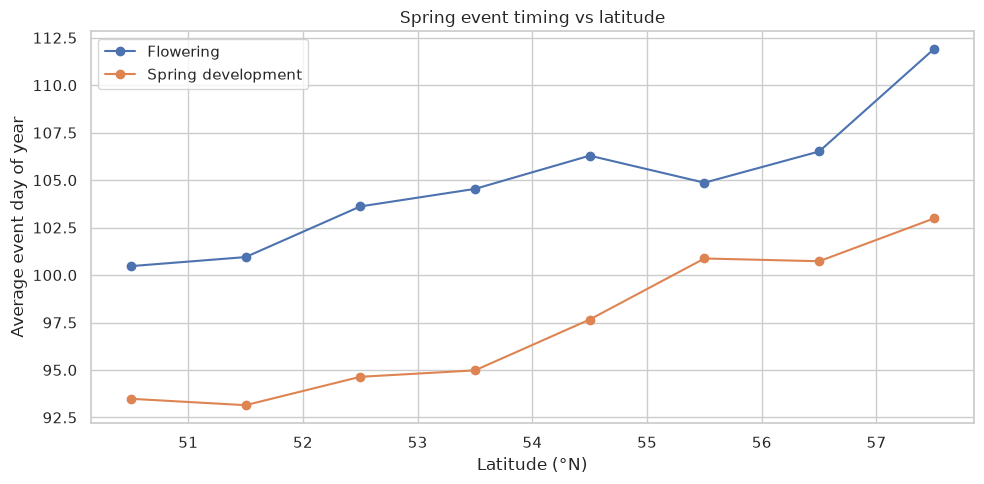

In [ ]:

q3 = f"""
    SELECT l.lat_band,
           AVG(l.band_lat)         AS band_lat,
           ec.event_category,
           AVG(f.day_of_year)      AS avg_event_day
    FROM fact_phenology_observation f
    JOIN dim_location l        ON l.location_id        = f.location_id
    JOIN dim_event e           ON e.event_id           = f.event_id
    JOIN dim_event_category ec ON ec.event_category_id = e.event_category_id
    WHERE ec.event_category IN {SPRING_EVENTS}
    GROUP BY l.lat_band, ec.event_category
    HAVING COUNT(*) > 200
    ORDER BY band_lat
"""
df3 = pd.read_sql(q3, engine)
 
fig, ax = plt.subplots(figsize=(10, 5))
for cat, g in df3.groupby("event_category"):
    g = g.sort_values("band_lat")
    ax.plot(g.band_lat, g.avg_event_day, "o-", label=cat)
ax.set_xlabel("Latitude (°N)")
ax.set_ylabel("Average event day of year")
ax.set_title("Spring event timing vs latitude")
ax.legend()
plt.tight_layout()
plt.show()


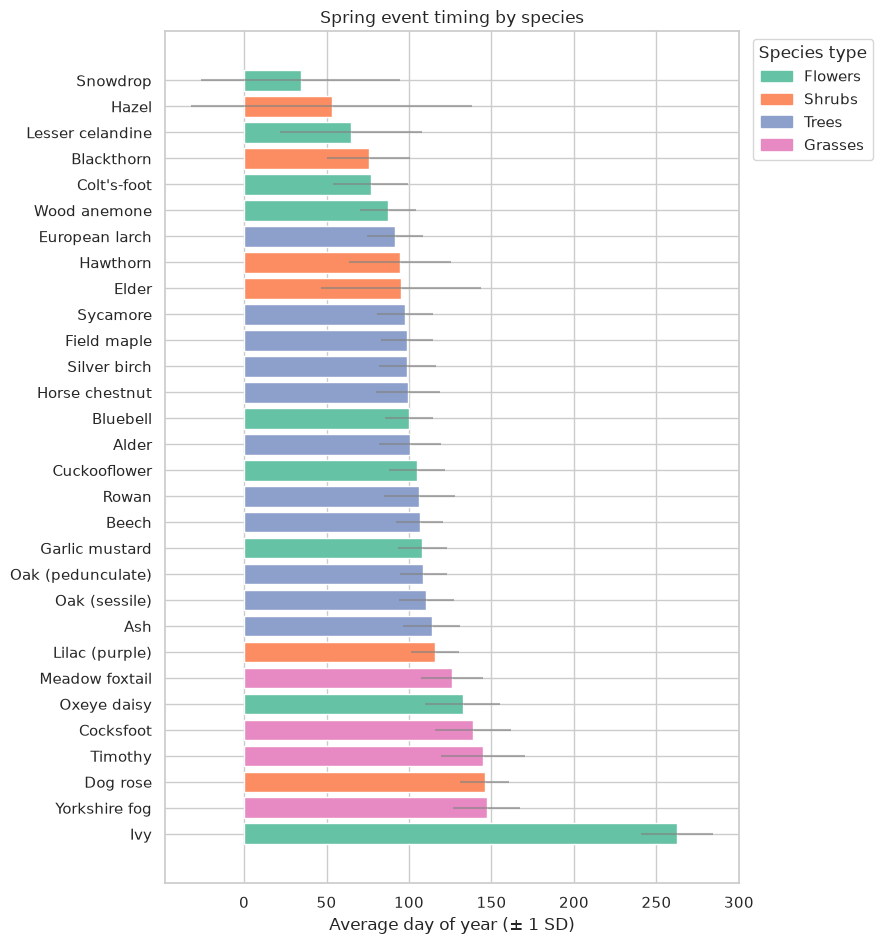

In [12]:
q5 = f"""
    SELECT s.species, st.species_type,
           AVG(f.day_of_year)    AS avg_event_day,
           STDDEV(f.day_of_year) AS std_event_day,
           COUNT(*)              AS n
    FROM fact_phenology_observation f
    JOIN dim_species s         ON s.species_id         = f.species_id
    JOIN dim_species_type st   ON st.species_type_id   = s.species_type_id
    JOIN dim_event e           ON e.event_id           = f.event_id
    JOIN dim_event_category ec ON ec.event_category_id = e.event_category_id
    WHERE ec.event_category IN {SPRING_EVENTS}
    GROUP BY s.species, st.species_type
    HAVING COUNT(*) > 200
    ORDER BY avg_event_day
"""
df5 = pd.read_sql(q5, engine)
 
palette = dict(zip(df5.species_type.unique(),
                   sns.color_palette("Set2", df5.species_type.nunique())))
 
fig, ax = plt.subplots(figsize=(9, max(5, 0.32 * len(df5))))
ax.barh(df5.species, df5.avg_event_day, xerr=df5.std_event_day,
        color=[palette[t] for t in df5.species_type],
        error_kw={"ecolor": "grey", "alpha": 0.6})
ax.invert_yaxis()
ax.set_xlabel("Average day of year (± 1 SD)")
ax.set_title("Spring event timing by species")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()]
ax.legend(handles, palette.keys(), title="Species type",
          bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


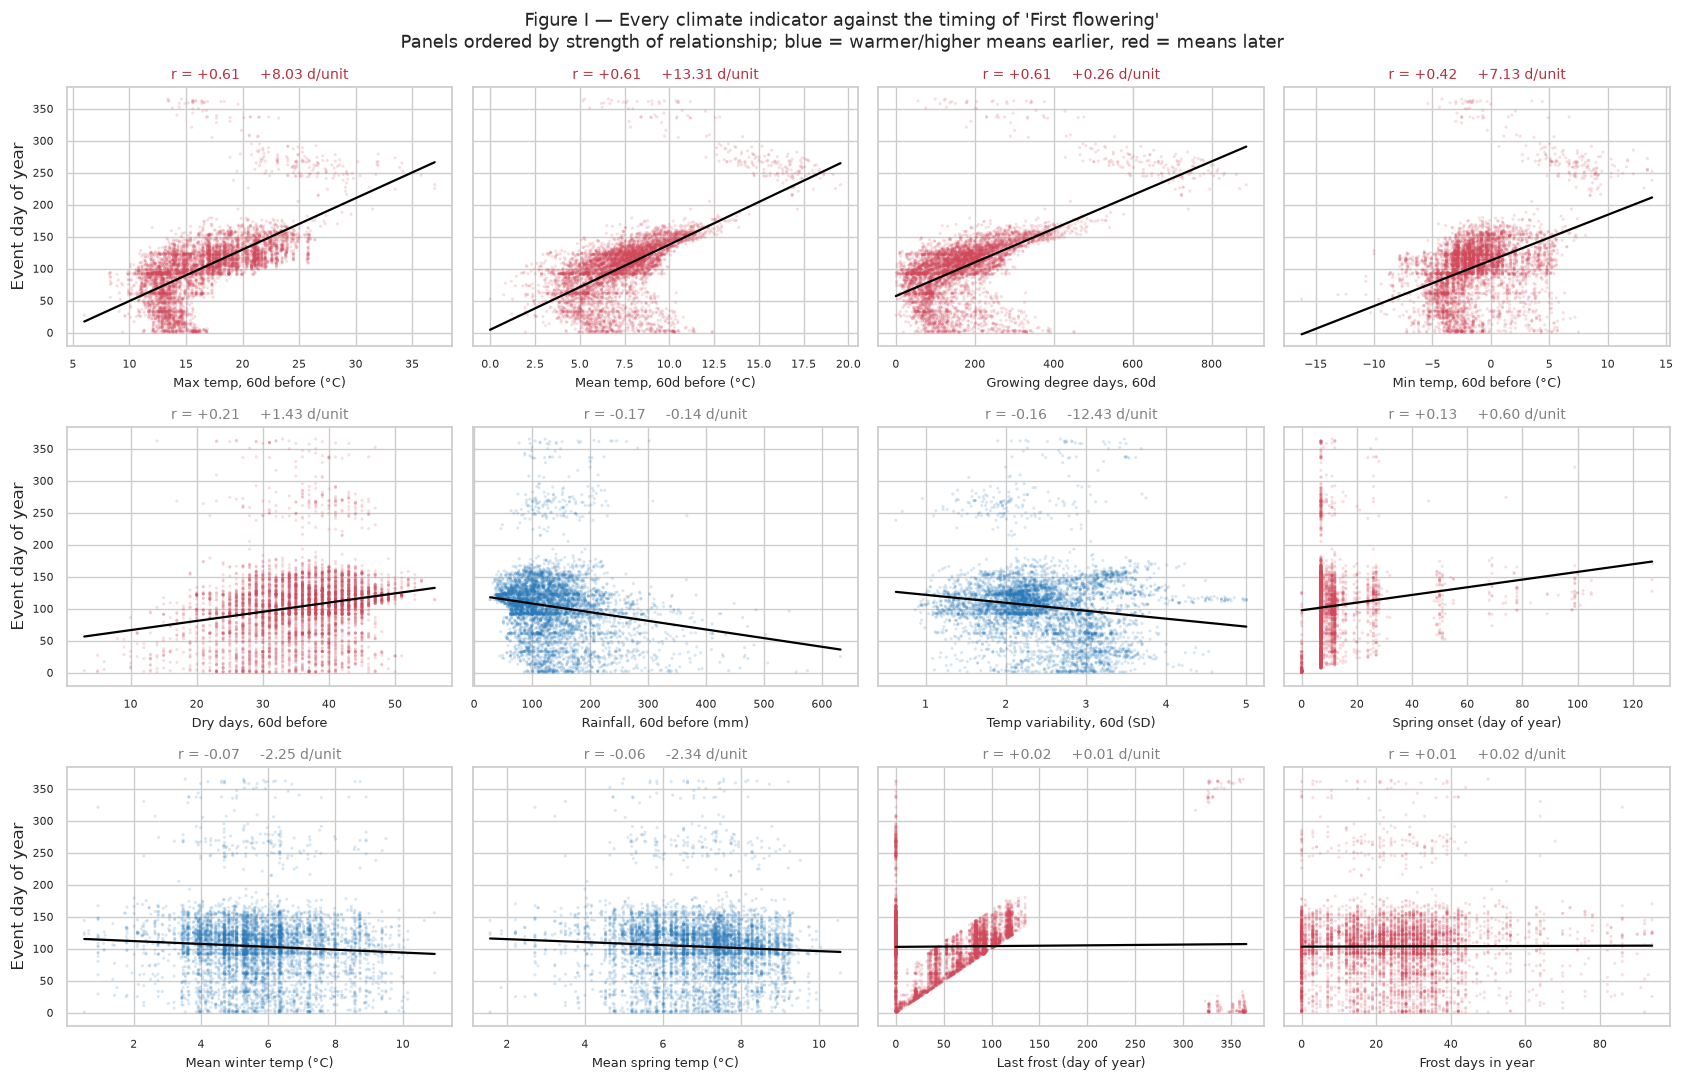

In [8]:
EVENT = "First flowering" 

INDICATORS = [
    ("temp_mean_window",  "Mean temp, 60d before (°C)"),
    ("gdd_window",        "Growing degree days, 60d"),
    ("temp_max_window",   "Max temp, 60d before (°C)"),
    ("temp_min_window",   "Min temp, 60d before (°C)"),
    ("temp_std_window",   "Temp variability, 60d (SD)"),
    ("precip_sum_window", "Rainfall, 60d before (mm)"),
    ("dry_days_window",   "Dry days, 60d before"),
    ("temp_mean_spring",  "Mean spring temp (°C)"),
    ("temp_mean_winter",  "Mean winter temp (°C)"),
    ("last_frost_doy",    "Last frost (day of year)"),
    ("spring_onset_doy",  "Spring onset (day of year)"),
    ("frost_days_year",   "Frost days in year"),
]

# Slope and correlation over the full table
stats_sql = ",\n".join(
    f"       CORR(f.day_of_year, f.{c}) AS r_{c},\n"
    f"       REGR_SLOPE(f.day_of_year, f.{c}) AS b_{c}"
    for c, _ in INDICATORS
)
stats = pd.read_sql(f"""
    SELECT
{stats_sql}
    FROM fact_phenology_observation f
    JOIN dim_event e ON e.event_id = f.event_id
    WHERE e.event = '{EVENT}'
""", engine).iloc[0]

# Sampled rows for the scatter itself
cols = ", ".join(f"f.{c}" for c, _ in INDICATORS)
pts = pd.read_sql(f"""
    SELECT f.day_of_year, {cols}
    FROM fact_phenology_observation f
    JOIN dim_event e ON e.event_id = f.event_id
    WHERE e.event = '{EVENT}'
    ORDER BY random()
    LIMIT 6000
""", engine)

# Order panels by strength of relationship
ordered = sorted(INDICATORS,
                 key=lambda ci: -abs(stats[f"r_{ci[0]}"] or 0))

fig, axes = plt.subplots(3, 4, figsize=(17, 11), sharey=True)
for ax, (col, label) in zip(axes.flatten(), ordered):
    r = stats[f"r_{col}"]
    b = stats[f"b_{col}"]
    x = pts[col].astype(float)
    y = pts["day_of_year"].astype(float)

    ax.scatter(x, y, s=5, alpha=0.18,
               color="#d1495b" if (r or 0) > 0 else "#2b7bba",
               edgecolors="none")

    # Fitted line from the SQL slope, anchored at the sample means
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, y.mean() + b * (xs - x.mean()), color="black", lw=1.6)

    ax.set_xlabel(label, fontsize=9)
    ax.set_title(f"r = {r:+.2f}     {b:+.2f} d/unit",
                 fontsize=10,
                 color="#b3303f" if abs(r) > 0.3 else "grey")
    ax.tick_params(labelsize=8)

for ax in axes[:, 0]:
    ax.set_ylabel("Event day of year")

fig.suptitle(f"Figure I — Every climate indicator against the timing of "
             f"'{EVENT}'\n"
             "Panels ordered by strength of relationship; "
             "blue = warmer/higher means earlier, red = means later",
             fontsize=13)
plt.tight_layout()
plt.show()

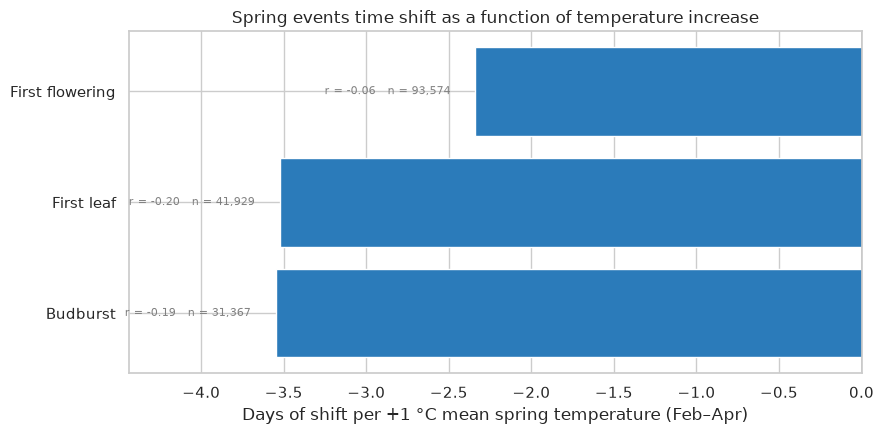

In [11]:
qa = """
    SELECT e.event,
           REGR_SLOPE(f.day_of_year, f.temp_mean_spring) AS days_per_degree,
           CORR(f.day_of_year, f.temp_mean_spring)       AS r,
           AVG(f.day_of_year)                            AS avg_doy,
           COUNT(*)                                      AS n
    FROM fact_phenology_observation f
    JOIN dim_event e ON e.event_id = f.event_id
    WHERE e.event IN ('Budburst', 'First leaf', 'First flowering')
    GROUP BY e.event
    ORDER BY days_per_degree
"""
dfa = pd.read_sql(qa, engine)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(dfa.event, dfa.days_per_degree, color="#2b7bba")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Days of shift per +1 °C mean spring temperature (Feb–Apr)")
ax.set_title("Spring events time shift as a function of temperature increase")

for y, (v, r, n) in enumerate(zip(dfa.days_per_degree, dfa.r, dfa.n)):
    ax.text(v - 0.15, y, f"r = {r:+.2f}   n = {n:,}",
            va="center", ha="right", fontsize=8, color="grey")

ax.margins(x=0.25)
plt.tight_layout()
plt.show()